# LG, 두산, 키움 연도별 관중수 예측 분석 (최종 수정본)
## [분석 개요]
2023~2025 KBO 수도권 3팀(LG, 두산, 키움)의 관중수 예측을 수행합니다.

## [데이터 스플릿 전략]
* **Train**: 각 연도 개막일 ~ 8월 31일
* **Test**: 각 연도 9월 1일 ~ 시즌 종료일
이 과정을 2023, 2024, 2025년 각각 독립적으로 수행합니다.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# 한국어 폰트 설정
import matplotlib.font_manager as fm
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

In [6]:
# 기존 코드 아래에 추가
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# [확인용] 현재 실제로 적용된 폰트 이름 출력
print(f"설정된 폰트: {plt.rcParams['font.family']}") 

# 만약 여기서 'Malgun Gothic'이 안 나온다면 아래 2번 방법을 쓰세요.

설정된 폰트: ['Malgun Gothic']


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. 데이터 로드 및 병합
kbo_df = pd.read_csv('KBO_2023_2025_FINAL_MASTER_2160.csv', encoding='utf-8-sig')
weather_df = pd.read_csv('KBO_Weather_Combined_2023_2025.csv', encoding='utf-8-sig')

# 컬럼명 정리 및 날짜 통일
kbo_df.columns = kbo_df.columns.str.strip()
weather_df = weather_df.rename(columns={'일시': '날짜'})
weather_df.columns = weather_df.columns.str.strip()

# [수정] 지점 타입 통일 및 날짜 변환 (에러 방지)
kbo_df['날짜'] = pd.to_datetime(kbo_df['날짜'])
weather_df['날짜'] = pd.to_datetime(weather_df['날짜'])
kbo_df['지점'] = kbo_df['지점'].fillna(0).astype(int)
weather_df['지점'] = weather_df['지점'].fillna(0).astype(int)

# 병합
df = pd.merge(kbo_df, weather_df, on=['지점', '날짜'], how='left')

# 2. 구장 데이터 정제
df.loc[(df['홈'] == 'NC') & (df['구장'] == '사직'), '구장'] = '창원'
main_stadiums = ['고척', '잠실', '수원', '광주', '문학', '대구', '창원', '사직', '한밭', '대전']
df = df[df['구장'].isin(main_stadiums)].copy()
df['구장'] = df['구장'].replace({'한밭': '대전'})

# 3. 시간 관련 변수 생성
df['datetime'] = pd.to_datetime(df['날짜'].dt.strftime('%Y-%m-%d') + ' ' + df['경기_시간'].astype(str))
df['연도'] = df['datetime'].dt.year
df['월'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['주말'] = df['weekday'].isin([5, 6]).astype(int)

# 4. 정교한 수용인원(Capacity) 설정
def map_capacity(row):
    stadium = row['구장']
    year = row['연도']
    cap = {'고척': 16000, '잠실': 23750, '수원': 18700, '광주': 20500, '문학': 23000, '대구': 24000, '창원': 17891}
    if stadium in cap: return cap[stadium]
    if stadium == '사직':
        return 22990 if year == 2023 else (22758 if year == 2024 else 22669)
    if stadium == '대전':
        return 12000 if year <= 2024 else 17000
    return np.nan

df['Capacity'] = df.apply(map_capacity, axis=1)
df['Actual_Attendance'] = df['관중수']

# 5. 날씨 파생 변수 및 결측치 처리
# [수정] 기온 결측치도 평균으로 보정
df['평균기온(°C)'] = df['평균기온(°C)'].fillna(df['평균기온(°C)'].mean())
df['평균 상대습도(%)'] = df['평균 상대습도(%)'].fillna(df['평균 상대습도(%)'].mean())

T = df['평균기온(°C)']
RH = df['평균 상대습도(%)']
df['불쾌지수'] = (9/5 * T) - 0.55 * (1 - RH/100) * (9/5 * T - 26) + 32

# 6. 일정 및 팀 성적 모멘텀 (Leakage 방지)
df = df.sort_values(['datetime']).reset_index(drop=True)

df['홈_승리_point'] = np.where(df['홈_점수'] > df['방문_점수'], 1.0, np.where(df['홈_점수'] == df['방문_점수'], 0.5, 0.0))
df['홈_최근10경기승률'] = df.groupby(['연도', '홈'])['홈_승리_point'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
).fillna(0.5)

df['시즌진행_경기수'] = df.groupby(['연도', '홈']).cumcount() + 1
df['시즌_진행률'] = df['시즌진행_경기수'] / 72.0
df['순위경쟁도'] = np.where(df['월'] >= 8, df['시즌_진행률'] * df['홈_최근10경기승률'], df['홈_최근10경기승률'] * 0.5)

# 7. 휴일 및 인기도 정보
holidays_full = [
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-03-01', '2023-05-01', '2023-05-05', 
    '2023-05-27', '2023-05-29', '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30', '2023-10-02', 
    '2023-10-03', '2023-10-09', '2023-12-25',
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-03-01', '2024-04-10', '2024-05-01', 
    '2024-05-05', '2024-05-06', '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17', '2024-09-18', 
    '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25',
    '2025-01-01', '2025-01-28', '2025-01-29', '2025-01-30', '2025-03-01', '2025-03-03', '2025-05-01', '2025-05-05', 
    '2025-05-06', '2025-06-06', '2025-08-15', '2025-10-03', '2025-10-05', '2025-10-06', '2025-10-07', '2025-10-08', 
    '2025-10-09', '2025-12-25'
]

df['is_holiday'] = df['날짜'].dt.date.astype(str).isin(holidays_full) | df['요일'].isin(['토', '일'])
df['is_holiday'] = df['is_holiday'].astype(int)

# [수정] 인기도: 리얼타임 성격 반영 (과거 데이터만 활용)
df['홈팀_인기도'] = df.groupby('홈')['관중수'].transform(lambda x: x.shift(1).expanding().mean()).fillna(df.groupby('홈')['관중수'].transform('mean'))
df['원정팀_인기도'] = df.groupby('방문')['관중수'].transform(lambda x: x.shift(1).expanding().mean()).fillna(df.groupby('방문')['관중수'].transform('mean'))

# 라이벌 매치
rivals = [('LG', '두산'), ('두산', 'LG'), ('롯데', 'LG'), ('LG', '롯데'), ('KIA', '한화'),('한화', 'KIA'), ('삼성', '롯데'),('롯데', '삼성')]
df['라이벌매치'] = df.apply(lambda row: int((row['홈'], row['방문']) in rivals), axis=1)

# [수정] 컬럼명 불일치 해결 (Game_Count -> 시즌진행_경기수)
df['Home_Games_Remaining'] = 72 - df['시즌진행_경기수']

# 8. 최종 데이터 정리 및 분할
# 지점은 더 이상 필요 없으므로 삭제
df.drop(['지점'], axis=1, inplace=True, errors='ignore')

# 타겟팀 필터링 (LG, 두산, 키움 홈 경기)
target_teams = ['LG', '두산', '키움']
df_filtered = df[df['홈'].isin(target_teams)].copy()

# 학습/테스트 데이터 분할
train_df = df_filtered[(df_filtered['datetime'] >= '2023-04-01') & (df_filtered['datetime'] <= '2025-07-31 23:59:59')].copy()
test_df = df_filtered[(df_filtered['datetime'] >= '2025-08-01') & (df_filtered['datetime'] <= '2025-10-31 23:59:59')].copy()

print(f"최종 분석 대상 경기 수(서울 연고팀): {len(df_filtered)}건")
print(f"학습 데이터: {len(train_df)}건 / 테스트 데이터: {len(test_df)}건")

최종 분석 대상 경기 수(서울 연고팀): 647건
학습 데이터: 588건 / 테스트 데이터: 59건


# [EDA] 수도권 3팀(LG, 두산, 키움) 관중 데이터 분석
## 1. 구장별/팀별/연도별 관중 현황 분석
## 2. 날씨(기온, 불쾌지수) 및 고척 돔구장의 계절적 특성
## 3. 팀 성적(최근 10경기 승률)과 관중수의 상관관계

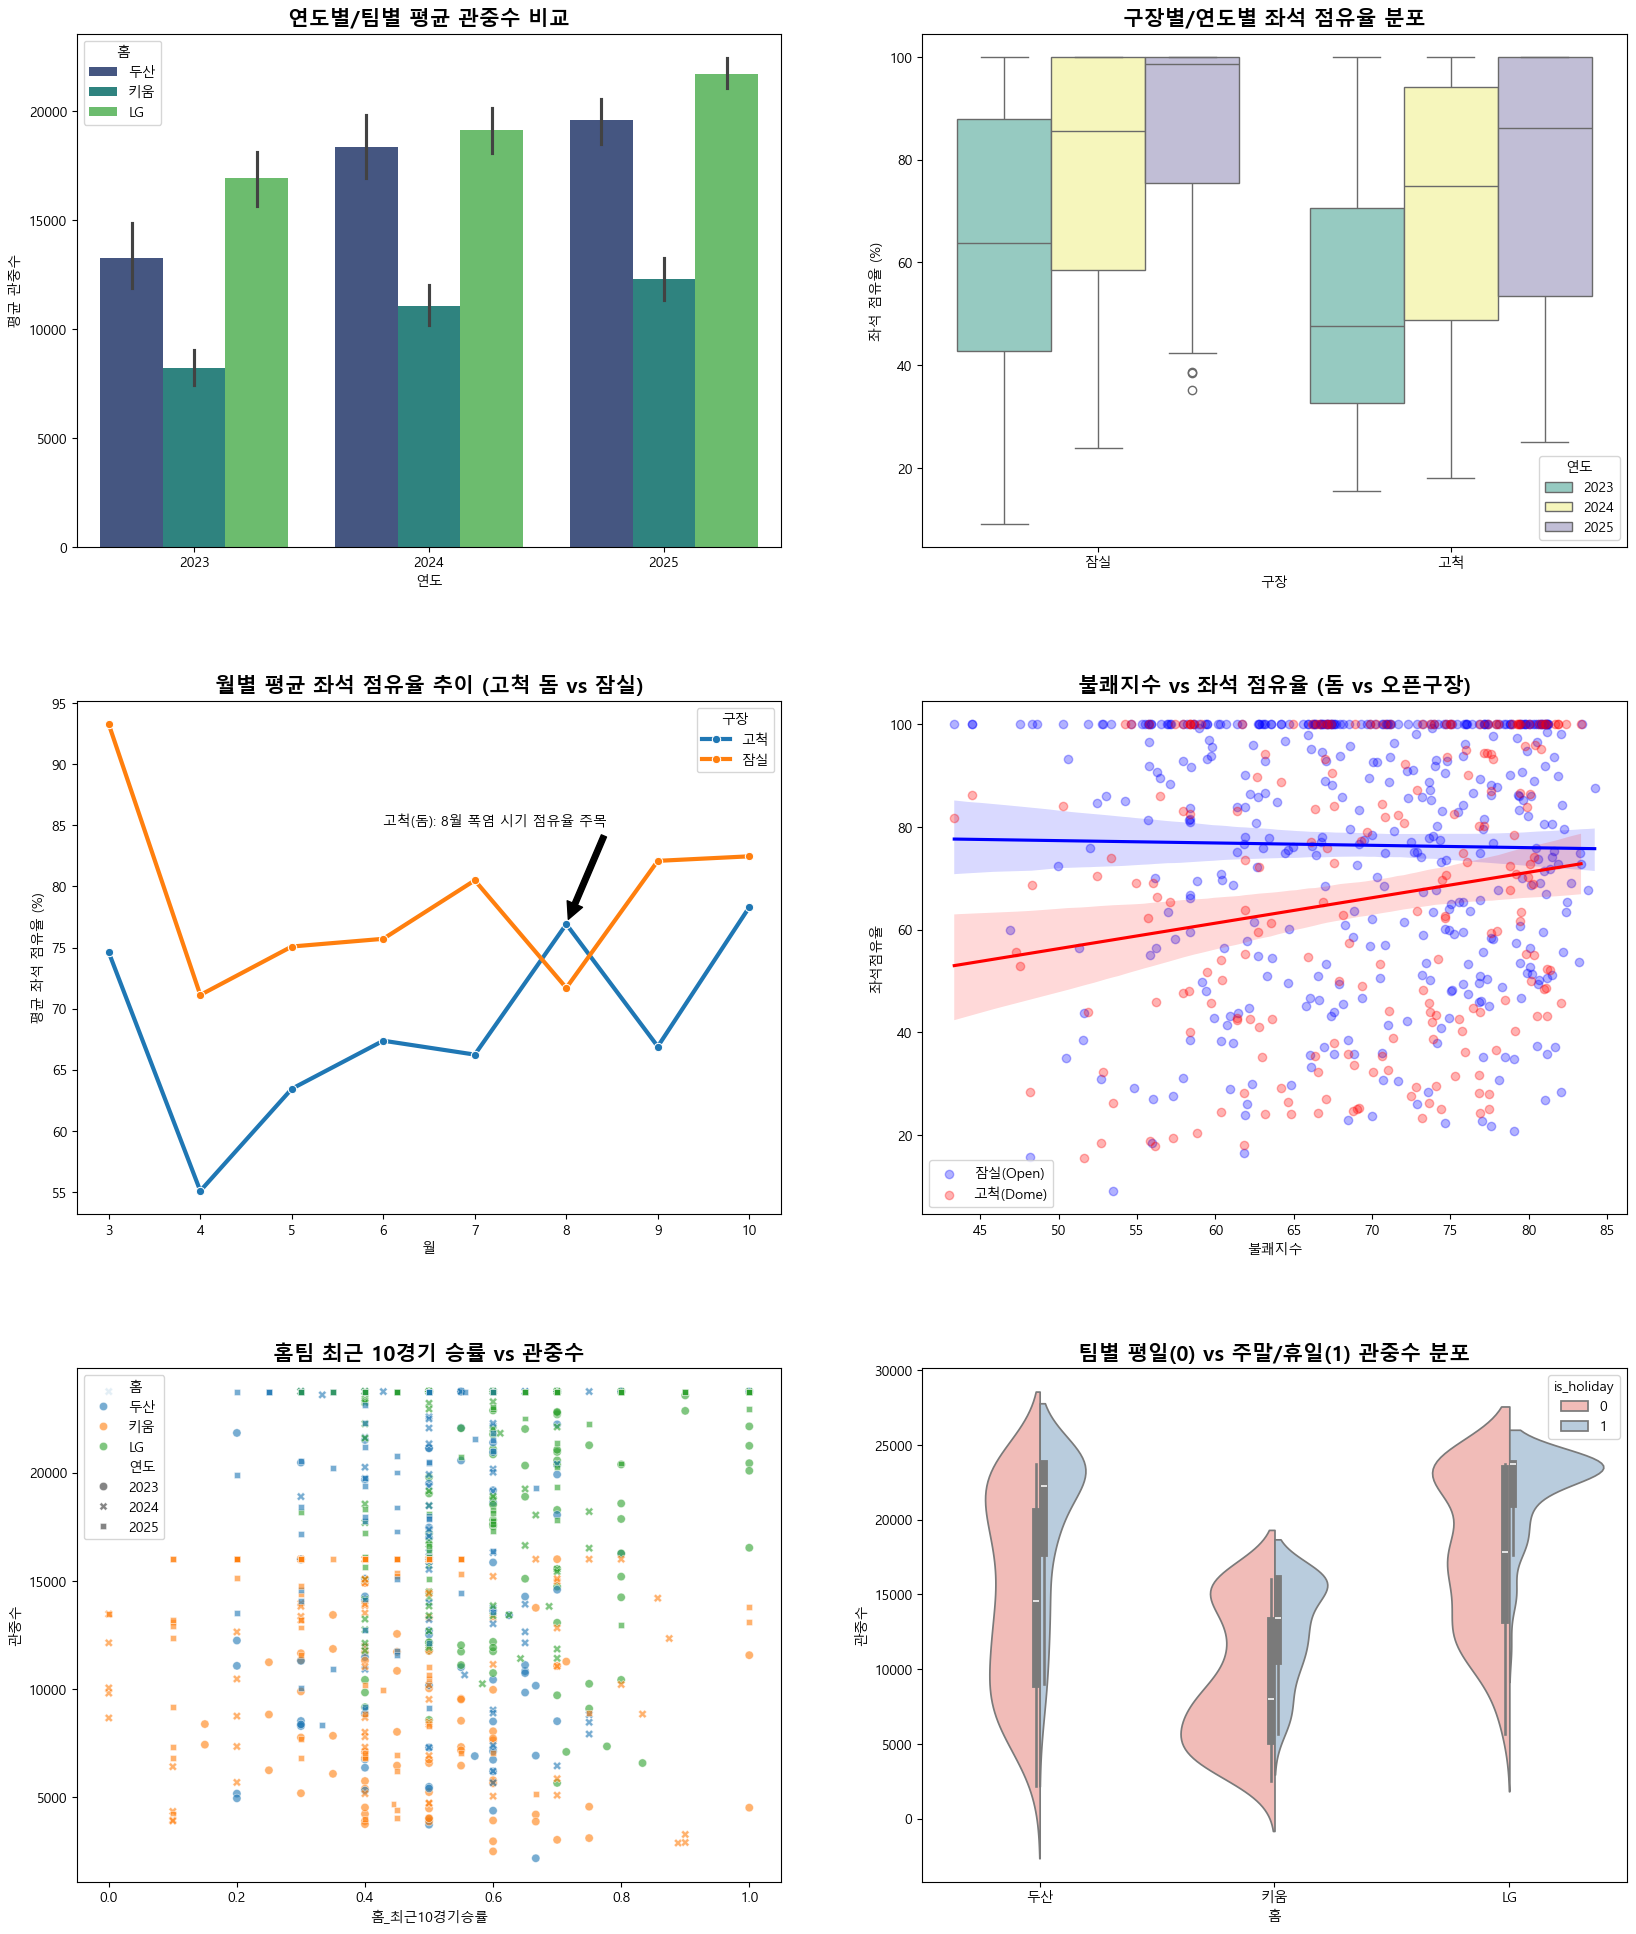

[분석 결과] 8월 평균 좌석 점유율 -> 고척(돔): 76.92% | 잠실: 71.70%
=> 고척 돔구장이 8월 폭염/우천 시기에 잠실보다 상대적으로 높은 점유율을 기록하는 경향이 확인되었습니다.


In [8]:
# EDA 데이터 준비
eda_df = df_filtered.copy()
eda_df['좌석점유율'] = (eda_df['관중수'] / eda_df['Capacity']) * 100

fig, axes = plt.subplots(3, 2, figsize=(20, 24))
plt.subplots_adjust(hspace=0.3)

# 1. 연도별/팀별 평균 관중수 비교
sns.barplot(data=eda_df, x='연도', y='관중수', hue='홈', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('연도별/팀별 평균 관중수 비교', fontsize=15, fontweight='bold')
axes[0, 0].set_ylabel('평균 관중수')

# 2. 구장별 좌석 점유율 분포 (Boxplot)
sns.boxplot(data=eda_df, x='구장', y='좌석점유율', hue='연도', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('구장별/연도별 좌석 점유율 분포', fontsize=15, fontweight='bold')
axes[0, 1].set_ylabel('좌석 점유율 (%)')

# 3. 월별 좌석 점유율 추이 (고척 vs 잠실)
monthly_occupancy = eda_df.groupby(['월', '구장'])['좌석점유율'].mean().reset_index()
sns.lineplot(data=monthly_occupancy, x='월', y='좌석점유율', hue='구장', marker='o', ax=axes[1, 0], linewidth=3)
axes[1, 0].set_title('월별 평균 좌석 점유율 추이 (고척 돔 vs 잠실)', fontsize=15, fontweight='bold')
axes[1, 0].set_ylabel('평균 좌석 점유율 (%)')
axes[1, 0].annotate('고척(돔): 8월 폭염 시기 점유율 주목', xy=(8, monthly_occupancy[(monthly_occupancy['월']==8) & (monthly_occupancy['구장']=='고척')]['좌석점유율'].values[0]), 
                xytext=(6, 85), arrowprops=dict(facecolor='black', shrink=0.05))

# 4. 불쾌지수에 따른 관중수 변화 (Scatter Plot with Regression Line)
sns.regplot(data=eda_df[eda_df['구장']=='잠실'], x='불쾌지수', y='좌석점유율', scatter_kws={'alpha':0.3}, label='잠실(Open)', ax=axes[1, 1], color='blue')
sns.regplot(data=eda_df[eda_df['구장']=='고척'], x='불쾌지수', y='좌석점유율', scatter_kws={'alpha':0.3}, label='고척(Dome)', ax=axes[1, 1], color='red')
axes[1, 1].set_title('불쾌지수 vs 좌석 점유율 (돔 vs 오픈구장)', fontsize=15, fontweight='bold')
axes[1, 1].legend()

# 5. 최근 10경기 승률과 관중수의 관계
sns.scatterplot(data=eda_df, x='홈_최근10경기승률', y='관중수', hue='홈', style='연도', alpha=0.6, ax=axes[2, 0])
axes[2, 0].set_title('홈팀 최근 10경기 승률 vs 관중수', fontsize=15, fontweight='bold')

# 6. 주말/휴일 여부에 따른 관중수 차이
sns.violinplot(data=eda_df, x='홈', y='관중수', hue='is_holiday', split=True, ax=axes[2, 1], palette='Pastel1')
axes[2, 1].set_title('팀별 평일(0) vs 주말/휴일(1) 관중수 분포', fontsize=15, fontweight='bold')

plt.show()

# 고척 8월 특수성 심층 분석 출력
gocheok_aug = eda_df[(eda_df['구장'] == '고척') & (eda_df['월'] == 8)]['좌석점유율'].mean()
jamsil_aug = eda_df[(eda_df['구장'] == '잠실') & (eda_df['월'] == 8)]['좌석점유율'].mean()
print(f"[분석 결과] 8월 평균 좌석 점유율 -> 고척(돔): {gocheok_aug:.2f}% | 잠실: {jamsil_aug:.2f}%")
if gocheok_aug > jamsil_aug:
    print("=> 고척 돔구장이 8월 폭염/우천 시기에 잠실보다 상대적으로 높은 점유율을 기록하는 경향이 확인되었습니다.")


# 모델링

In [9]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

def train_advanced_ensemble(year):
    # 1. 데이터 준비
    data_year = df_filtered[df_filtered['연도'] == year].copy()
    train_data = data_year[data_year['날짜'] <= f'{year}-08-31'].copy()
    test_data = data_year[data_year['날짜'] > f'{year}-08-31'].copy()
    
    features = ['Capacity', '불쾌지수', '홈_최근10경기승률', '순위경쟁도', 'is_holiday', 
                '원정팀_인기도', 'Home_Games_Remaining', '시즌_진행률', '평균기온(°C)', '주말', '라이벌매치']
    
    X_train, y_train = train_data[features], train_data['Actual_Attendance']
    X_test, y_test = test_data[features], test_data['Actual_Attendance']

    # 2. 개별 모델 정의 (하이퍼파라미터는 KBO 특성에 맞춰 조정)
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
    lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
    cat = CatBoostRegressor(n_estimators=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)

    # 3. 앙상블 모델 정의
    # (1) Voting: 세 모델의 예측값을 평균냄
    voting_model = VotingRegressor([('xgb', xgb), ('lgbm', lgbm), ('cat', cat)])
    
    # (2) Stacking: 세 모델의 예측값을 바탕으로 최종 모델(Ridge)이 다시 학습
    stacking_model = StackingRegressor(
        estimators=[('xgb', xgb), ('lgbm', lgbm), ('cat', cat)],
        final_estimator=Ridge(alpha=1.0)
    )

    # 4. 비교 분석 대상 리스트
    models = {
        'XGB': xgb, 
        'LGBM': lgbm, 
        'CatBoost': cat, 
        'Voting': voting_model, 
        'Stacking': stacking_model
    }

    results_summary = []
    
    print(f"\n--- {year}년 모델별 배틀 결과 ---")
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = np.maximum(0, model.predict(X_test))
        
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        results_summary.append({'Model': name, 'R2': r2, 'MAE': mae})
        print(f"[{name}] R2: {r2:.4f} | MAE: {mae:.2f}")

    # 가장 R2가 높은 모델을 반환
    best_model_info = max(results_summary, key=lambda x: x['R2'])
    print(f"🏆 Best Model: {best_model_info['Model']}")
    
    return pd.DataFrame(results_summary), best_model_info

# 연도별로 최고 성능 모델 찾기
summary_2023, best_23 = train_advanced_ensemble(2023)
summary_2024, best_24 = train_advanced_ensemble(2024)
summary_2025, best_25 = train_advanced_ensemble(2025)


--- 2023년 모델별 배틀 결과 ---
[XGB] R2: 0.5420 | MAE: 3545.03
[LGBM] R2: 0.6091 | MAE: 3208.16
[CatBoost] R2: 0.4716 | MAE: 3716.83
[Voting] R2: 0.5682 | MAE: 3413.03
[Stacking] R2: 0.4434 | MAE: 3919.09
🏆 Best Model: LGBM

--- 2024년 모델별 배틀 결과 ---
[XGB] R2: 0.2358 | MAE: 2661.80
[LGBM] R2: 0.2999 | MAE: 2553.96
[CatBoost] R2: 0.2584 | MAE: 2942.26
[Voting] R2: 0.2902 | MAE: 2651.16
[Stacking] R2: 0.3887 | MAE: 2269.14
🏆 Best Model: Stacking

--- 2025년 모델별 배틀 결과 ---
[XGB] R2: 0.3415 | MAE: 2886.00
[LGBM] R2: 0.4896 | MAE: 2662.07
[CatBoost] R2: 0.5707 | MAE: 2712.99
[Voting] R2: 0.5020 | MAE: 2690.28
[Stacking] R2: 0.4958 | MAE: 2604.85
🏆 Best Model: CatBoost


In [10]:
# 모델 배틀 결과(results_2023 등)를 시각화 함수용 이름(res23 등)으로 복사합니다.
try:
    res23 = summary_2023 if 'summary_2023' in locals() else results_2023
    res24 = summary_2024 if 'summary_2024' in locals() else results_2024
    res25 = summary_2025 if 'summary_2025' in locals() else results_2025
    print("✅ 변수 준비 완료! 이제 아래 시각화 코드를 실행하세요.")
except NameError:
    print("❌ 아직 모델 학습 결과가 없습니다. 'train_advanced_ensemble' 코드를 먼저 실행해 주세요.")

✅ 변수 준비 완료! 이제 아래 시각화 코드를 실행하세요.


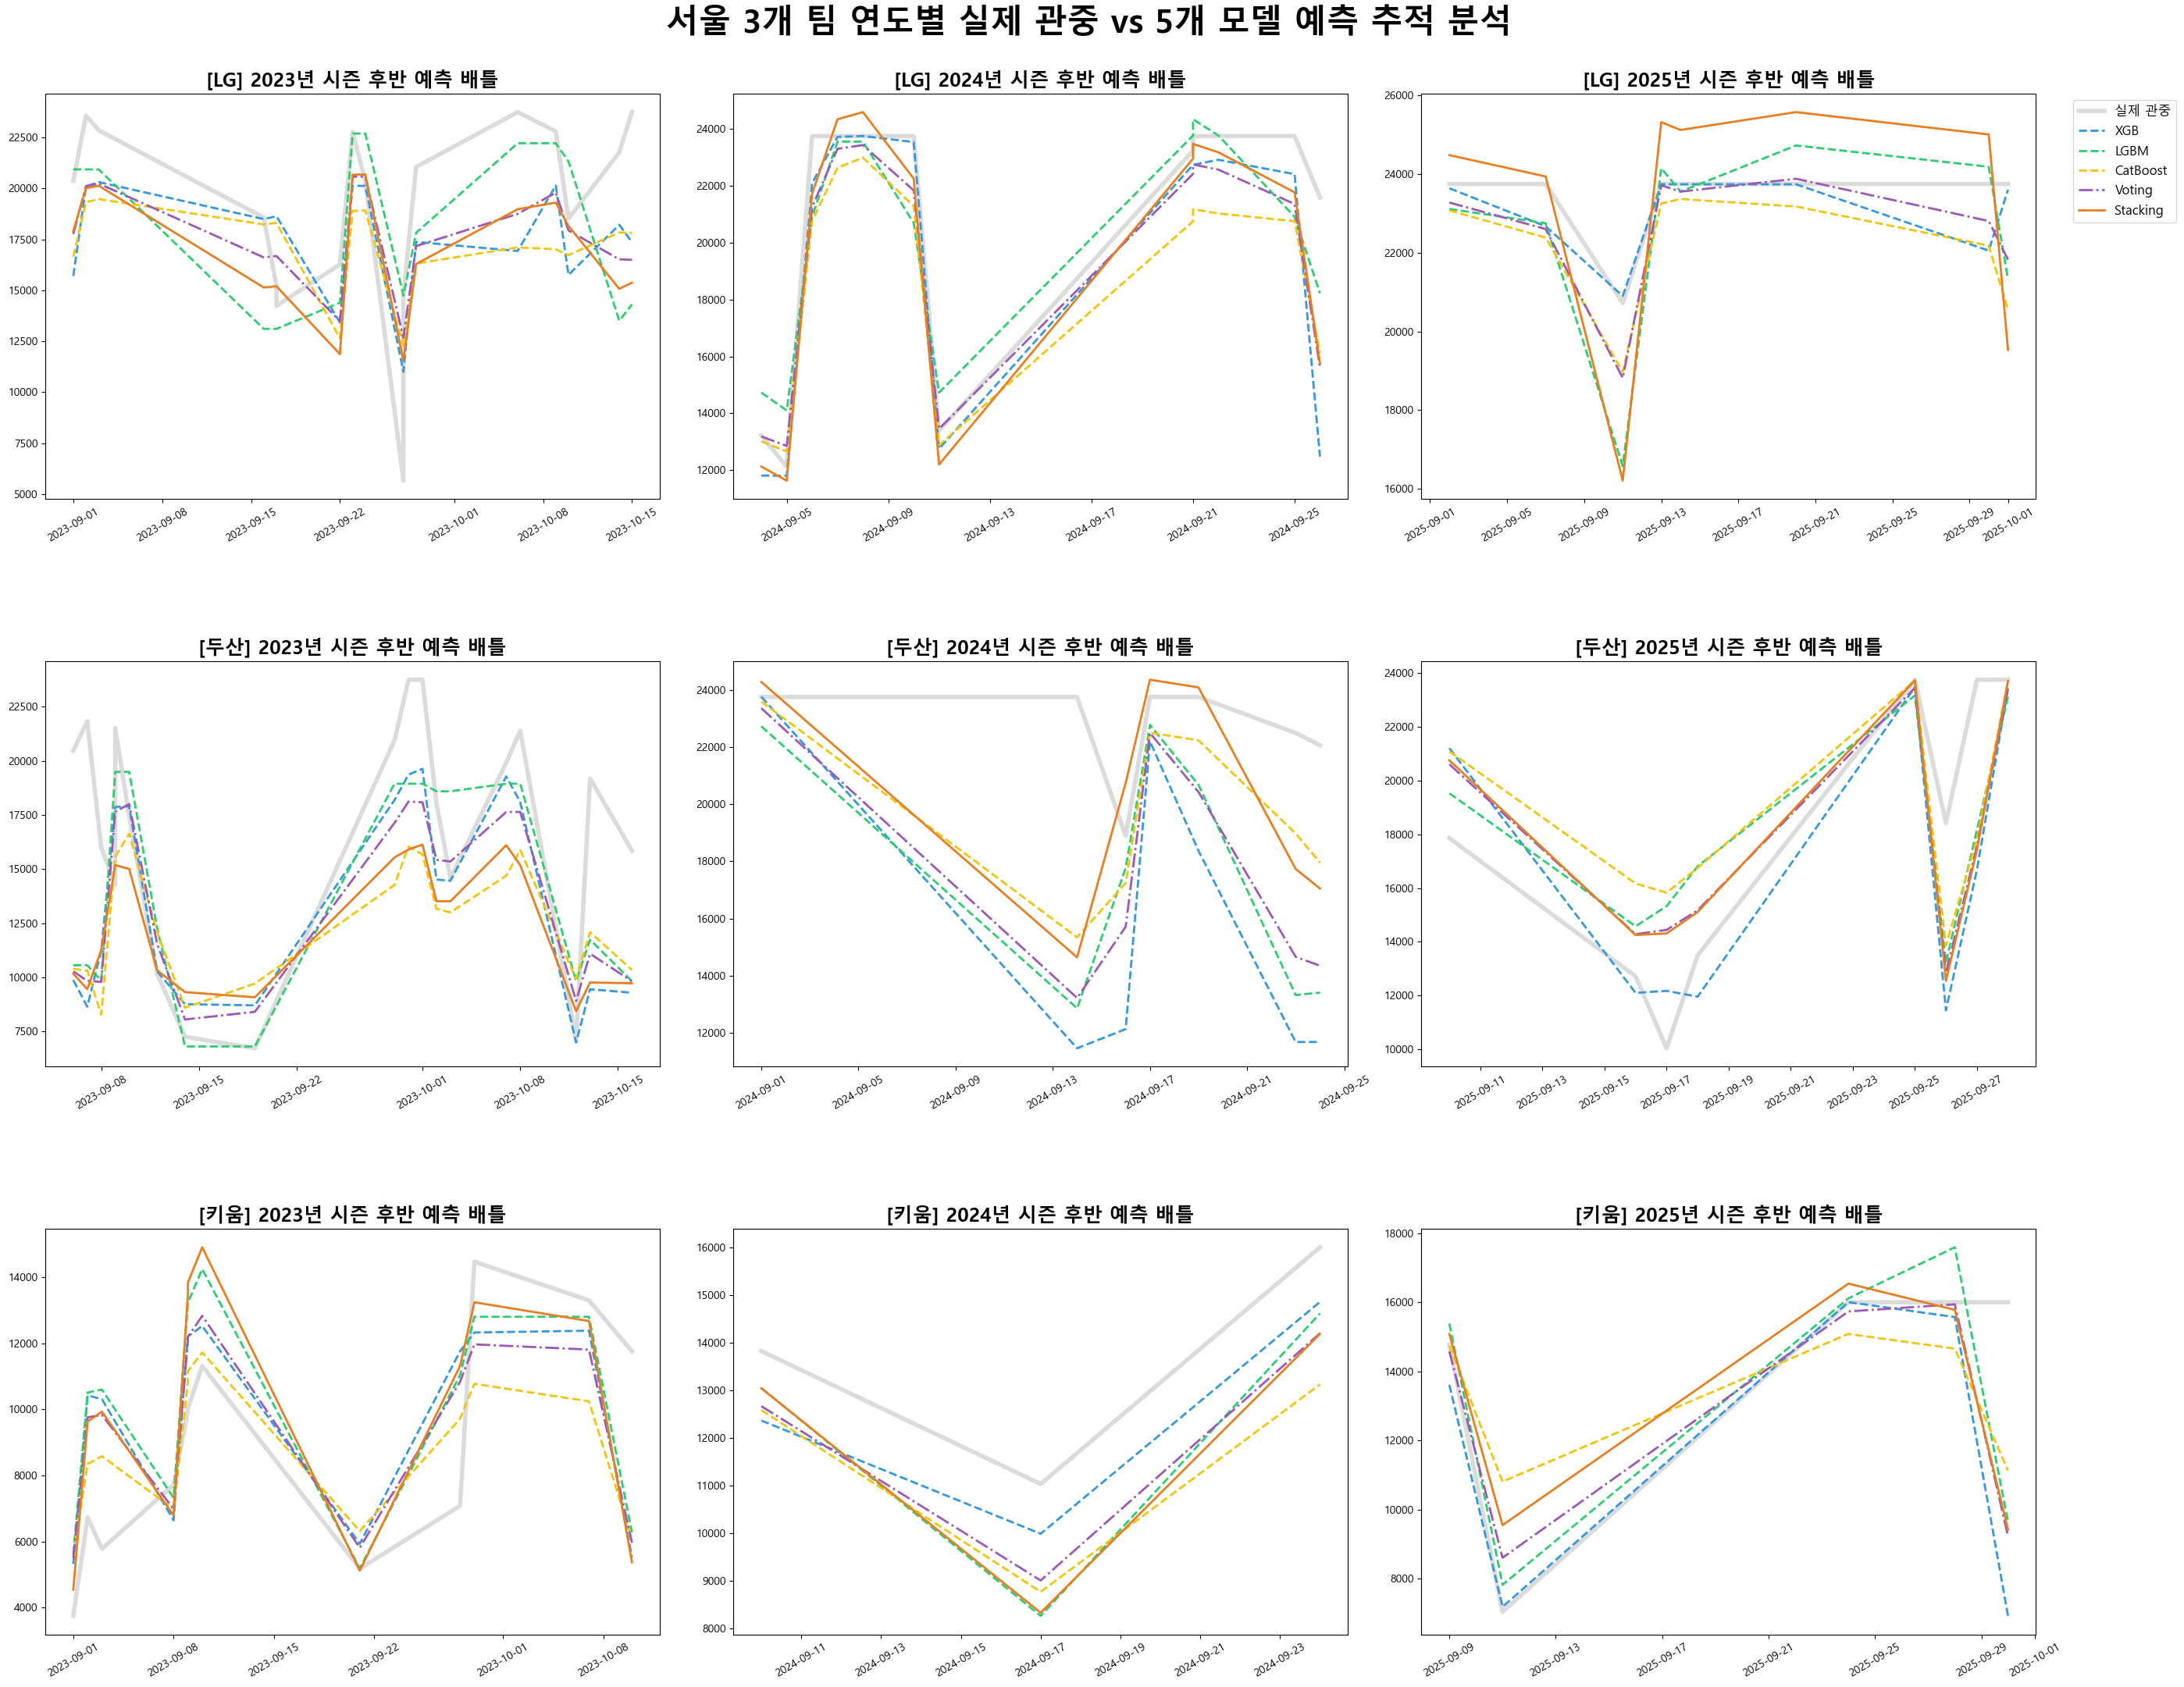

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

def plot_final_model_tracking(df_filtered):
    target_teams = ['LG', '두산', '키움']
    years = [2023, 2024, 2025]
    features = ['Capacity', '불쾌지수', '홈_최근10경기승률', '순위경쟁도', 'is_holiday', 
                '원정팀_인기도', 'Home_Games_Remaining', '시즌_진행률', '평균기온(°C)', '주말', '라이벌매치']
    
    # 모델별 색상 및 스타일
    model_cfg = {
        'XGB': {'color': '#3498db', 'ls': '--'},
        'LGBM': {'color': '#2ecc71', 'ls': '--'},
        'CatBoost': {'color': '#f1c40f', 'ls': '--'},
        'Voting': {'color': '#9b59b6', 'ls': '-.'},
        'Stacking': {'color': '#e67e22', 'ls': '-'} # 스태킹은 실선으로 강조
    }

    fig, axes = plt.subplots(3, 3, figsize=(28, 22))
    
    for row, team in enumerate(target_teams):
        for col, year in enumerate(years):
            # 1. 데이터 분리
            data_yr = df_filtered[(df_filtered['홈'] == team) & (df_filtered['연도'] == year)].copy()
            train_data = data_yr[data_yr['날짜'] <= f'{year}-08-31'].copy()
            test_data = data_yr[data_yr['날짜'] > f'{year}-08-31'].copy().sort_values('날짜')
            
            ax = axes[row, col]
            if len(test_data) == 0:
                ax.text(0.5, 0.5, '데이터 없음', ha='center')
                continue

            # 2. 실제값 (굵은 회색 배경선)
            ax.plot(test_data['날짜'], test_data['Actual_Attendance'], 
                    label='실제 관중', color='#D3D3D3', alpha=0.8, linewidth=4, zorder=1)

            # 3. 5개 모델 예측 (이미 정의된 파라미터로 즉시 fit & predict)
            X_train, y_train = train_data[features], train_data['Actual_Attendance']
            X_test = test_data[features]
            
            # 모델 객체 생성 (사용자님 파라미터와 동일)
            m_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
            m_lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
            m_cat = CatBoostRegressor(n_estimators=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
            
            models = {
                'XGB': m_xgb, 'LGBM': m_lgbm, 'CatBoost': m_cat,
                'Voting': VotingRegressor([('xgb', m_xgb), ('lgbm', m_lgbm), ('cat', m_cat)]),
                'Stacking': StackingRegressor(estimators=[('xgb', m_xgb), ('lgbm', m_lgbm), ('cat', m_cat)], 
                                              final_estimator=Ridge(alpha=1.0))
            }

            for name, model in models.items():
                model.fit(X_train, y_train) # 각 칸의 팀/연도 데이터로 최적화
                pred = np.maximum(0, model.predict(X_test))
                ax.plot(test_data['날짜'], pred, label=name, 
                        color=model_cfg[name]['color'], linestyle=model_cfg[name]['ls'], linewidth=2, zorder=2)

            # 그래프 꾸미기
            ax.set_title(f"[{team}] {year}년 시즌 후반 예측 배틀", fontsize=18, fontweight='bold')
            ax.tick_params(axis='x', rotation=30)
            if row == 0 and col == 2:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.4)
    fig.suptitle('서울 3개 팀 연도별 실제 관중 vs 5개 모델 예측 추적 분석', fontsize=30, fontweight='bold')
    plt.show()

# 실행
plot_final_model_tracking(df_filtered)

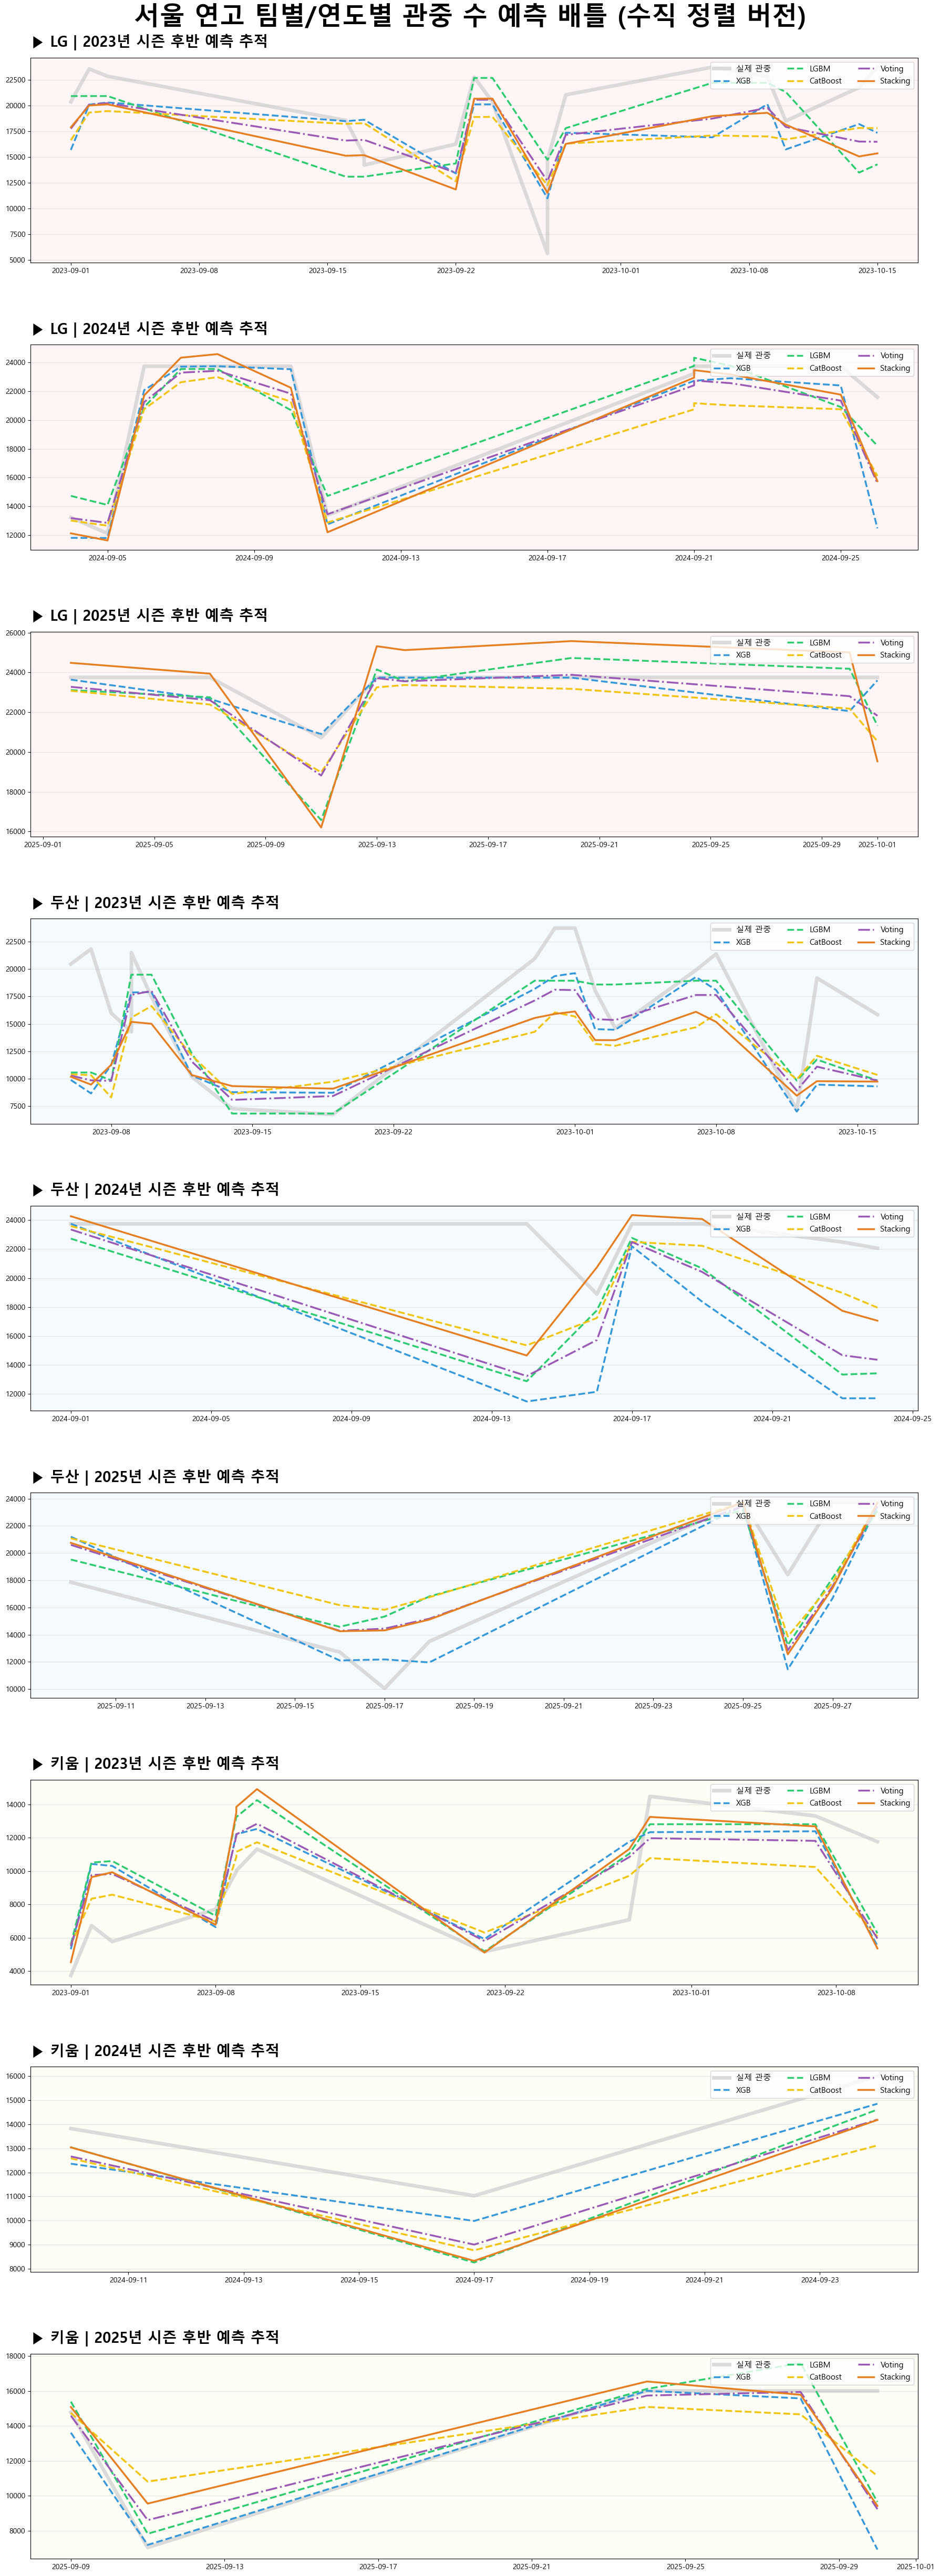

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.linear_model import Ridge

# 한글 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

def plot_vertical_team_tracking(df_filtered):
    target_teams = ['LG', '두산', '키움']
    years = [2023, 2024, 2025]
    features = ['Capacity', '불쾌지수', '홈_최근10경기승률', '순위경쟁도', 'is_holiday', 
                '원정팀_인기도', 'Home_Games_Remaining', '시즌_진행률', '평균기온(°C)', '주말', '라이벌매치']
    
    model_cfg = {
        'XGB': {'color': '#3498db', 'ls': '--'},
        'LGBM': {'color': '#2ecc71', 'ls': '--'},
        'CatBoost': {'color': '#f1c40f', 'ls': '--'},
        'Voting': {'color': '#9b59b6', 'ls': '-.'},
        'Stacking': {'color': '#e67e22', 'ls': '-'}
    }

    # 세로로 길게 9개의 그래프 생성 (3개 팀 x 3개 연도)
    fig, axes = plt.subplots(9, 1, figsize=(18, 50)) # 높이를 50으로 늘려 시원하게 배치
    
    idx = 0
    for team in target_teams:
        for year in years:
            data_yr = df_filtered[(df_filtered['홈'] == team) & (df_filtered['연도'] == year)].copy()
            train_data = data_yr[data_yr['날짜'] <= f'{year}-08-31'].copy()
            test_data = data_yr[data_yr['날짜'] > f'{year}-08-31'].copy().sort_values('날짜')
            
            ax = axes[idx]
            if len(test_data) == 0:
                ax.text(0.5, 0.5, f'{team} {year} 데이터 없음', ha='center', va='center', fontsize=15)
                idx += 1
                continue

            # 실제값 배경선
            ax.plot(test_data['날짜'], test_data['Actual_Attendance'], 
                    label='실제 관중', color='#D3D3D3', alpha=0.8, linewidth=5, zorder=1)

            # 모델 학습 및 예측
            X_train, y_train = train_data[features], train_data['Actual_Attendance']
            X_test = test_data[features]
            
            m_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
            m_lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
            m_cat = CatBoostRegressor(n_estimators=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
            
            models = {
                'XGB': m_xgb, 'LGBM': m_lgbm, 'CatBoost': m_cat,
                'Voting': VotingRegressor([('xgb', m_xgb), ('lgbm', m_lgbm), ('cat', m_cat)]),
                'Stacking': StackingRegressor(estimators=[('xgb', m_xgb), ('lgbm', m_lgbm), ('cat', m_cat)], 
                                              final_estimator=Ridge(alpha=1.0))
            }

            for name, model in models.items():
                model.fit(X_train, y_train)
                pred = np.maximum(0, model.predict(X_test))
                ax.plot(test_data['날짜'], pred, label=name, 
                        color=model_cfg[name]['color'], linestyle=model_cfg[name]['ls'], linewidth=2.5, zorder=2)

            # 팀별 배경색 미세 조정 (가독성용)
            bg_colors = {'LG': '#fff5f5', '두산': '#f5faff', '키움': '#fdfcf5'}
            ax.set_facecolor(bg_colors.get(team, 'white'))

            ax.set_title(f"▶ {team} | {year}년 시즌 후반 예측 추적", fontsize=20, fontweight='bold', loc='left', pad=15)
            ax.tick_params(axis='x', rotation=0) # 세로형은 가로폭이 넓어 회전 안 해도 잘 보임
            ax.legend(loc='upper right', fontsize=11, ncol=3) # 범례를 상단에 가로로 배치
            ax.grid(True, axis='y', alpha=0.3)
            
            idx += 1

    plt.tight_layout()
    plt.subplots_adjust(top=0.96, hspace=0.4)
    fig.suptitle('서울 연고 팀별/연도별 관중 수 예측 배틀 (수직 정렬 버전)', fontsize=35, fontweight='bold')
plt.show()

# 실행
plot_vertical_team_tracking(df_filtered)